In [1]:
# Forecasting Business-Unit Carbon Emissions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("klimatenet_bu_emissions - klimatenet_bu_emissions.csv")

In [4]:
df.head()

,date,business_unit_id,emissions_co2e,energy_consumption_kwh,production_volume,operational_hours,fuel_mix_fossil_pct,headcount,temperature_avg,maintenance_events,mitigation_action_flag,carbon_price_index,seasonality_strength
0,2021-01-04,BU_01,659.66,674.69,915.75,153.4,0.83,115,9.7,0,0,50.69,strong
1,2021-01-11,BU_01,832.28,823.54,903.73,156.8,0.74,105,19.0,2,0,46.21,strong
2,2021-01-18,BU_01,1017.82,635.45,1007.23,209.3,0.75,116,16.2,0,0,49.26,strong
3,2021-01-25,BU_01,1040.02,894.72,1090.23,175.8,0.61,141,21.3,0,0,48.17,strong
4,2021-02-01,BU_01,1044.10,1018.57,1011.96,149.9,0.70,114,20.9,0,0,47.75,strong


In [5]:
df.isnull().sum()

date                      0
business_unit_id          0
emissions_co2e            0
energy_consumption_kwh    0
production_volume         0
operational_hours         0
fuel_mix_fossil_pct       0
headcount                 0
temperature_avg           0
maintenance_events        0
mitigation_action_flag    0
carbon_price_index        0
seasonality_strength      0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    4320 non-null   object 
 1   business_unit_id        4320 non-null   object 
 2   emissions_co2e          4320 non-null   float64
 3   energy_consumption_kwh  4320 non-null   float64
 4   production_volume       4320 non-null   float64
 5   operational_hours       4320 non-null   float64
 6   fuel_mix_fossil_pct     4320 non-null   float64
 7   headcount               4320 non-null   int64  
 8   temperature_avg         4320 non-null   float64
 9   maintenance_events      4320 non-null   int64  
 10  mitigation_action_flag  4320 non-null   int64  
 11  carbon_price_index      4320 non-null   float64
 12  seasonality_strength    4320 non-null   object 
dtypes: float64(7), int64(3), object(3)
memory usage: 438.9+ KB


In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
print(df['seasonality_strength'].dtype)
print(df['seasonality_strength'].unique())

object
['strong' 'none' 'weak']


In [9]:
if df['seasonality_strength'].dtype == 'object':
    df['seasonality_strength'] = df['seasonality_strength'].str.lower().str.strip()
    df['seasonality_strength'] = df['seasonality_strength'].map({
        'low': 1,
        'medium': 2,
        'strong': 3
    })

In [10]:
df['seasonality_strength'] = df['seasonality_strength'].fillna(2)

In [11]:
print(df['seasonality_strength'].unique())
print(df.isnull().sum().sum())

[3. 2.]
0


In [12]:
df['seasonality_strength'].dtype
df['seasonality_strength'].unique()

array([3., 2.])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    4320 non-null   datetime64[ns]
 1   business_unit_id        4320 non-null   object        
 2   emissions_co2e          4320 non-null   float64       
 3   energy_consumption_kwh  4320 non-null   float64       
 4   production_volume       4320 non-null   float64       
 5   operational_hours       4320 non-null   float64       
 6   fuel_mix_fossil_pct     4320 non-null   float64       
 7   headcount               4320 non-null   int64         
 8   temperature_avg         4320 non-null   float64       
 9   maintenance_events      4320 non-null   int64         
 10  mitigation_action_flag  4320 non-null   int64         
 11  carbon_price_index      4320 non-null   float64       
 12  seasonality_strength    4320 non-null   float64 

In [14]:
df = pd.get_dummies(df, columns=['business_unit_id'], drop_first=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    4320 non-null   datetime64[ns]
 1   emissions_co2e          4320 non-null   float64       
 2   energy_consumption_kwh  4320 non-null   float64       
 3   production_volume       4320 non-null   float64       
 4   operational_hours       4320 non-null   float64       
 5   fuel_mix_fossil_pct     4320 non-null   float64       
 6   headcount               4320 non-null   int64         
 7   temperature_avg         4320 non-null   float64       
 8   maintenance_events      4320 non-null   int64         
 9   mitigation_action_flag  4320 non-null   int64         
 10  carbon_price_index      4320 non-null   float64       
 11  seasonality_strength    4320 non-null   float64       
 12  business_unit_id_BU_02  4320 non-null   bool    

In [16]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    4320 non-null   datetime64[ns]
 1   emissions_co2e          4320 non-null   float64       
 2   energy_consumption_kwh  4320 non-null   float64       
 3   production_volume       4320 non-null   float64       
 4   operational_hours       4320 non-null   float64       
 5   fuel_mix_fossil_pct     4320 non-null   float64       
 6   headcount               4320 non-null   int64         
 7   temperature_avg         4320 non-null   float64       
 8   maintenance_events      4320 non-null   int64         
 9   mitigation_action_flag  4320 non-null   int64         
 10  carbon_price_index      4320 non-null   float64       
 11  seasonality_strength    4320 non-null   float64       
 12  business_unit_id_BU_02  4320 non-null   int64   

In [ ]:
# EDA

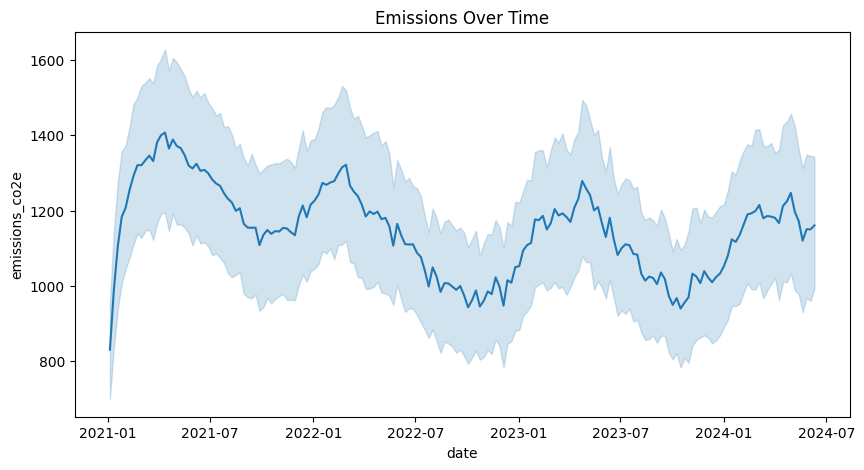

In [18]:
plt.figure(figsize=(10,5))
sns.lineplot(x='date', y='emissions_co2e', data=df)
plt.title("Emissions Over Time")
plt.show()

In [19]:
# Feature & Target
target = 'emissions_co2e'

X = df.drop(columns=['date', target])
y = df[target]

In [ ]:
# Train-Test Split (Time-Based)

In [20]:
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
# A.REGRESSION MODELS

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# 1. Linear Regression

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 537.6400279689667


In [ ]:
# 2. Random Forest

In [23]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 613.3260352837264


In [ ]:
# 3. Model Comparison

In [24]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf]
})

results

,Model,RMSE
0,Linear Regression,537.640028
1,Random Forest,613.326035


In [ ]:
# Feature Importance

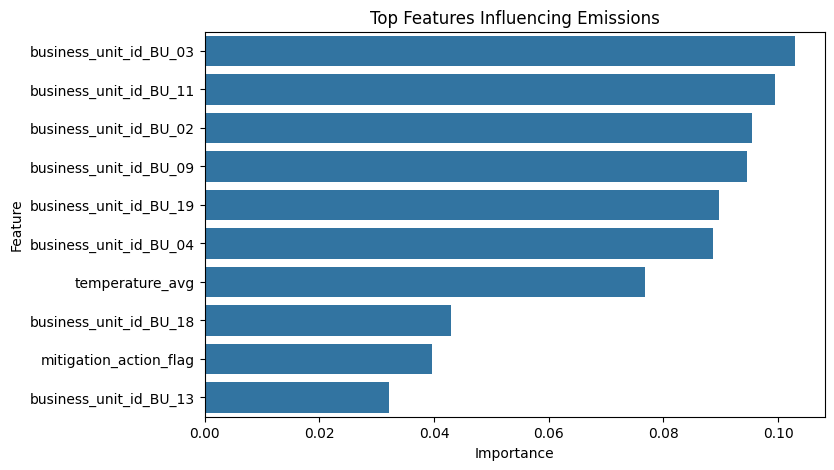

In [25]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top Features Influencing Emissions")
plt.show()

In [ ]:
# Residual Analysis

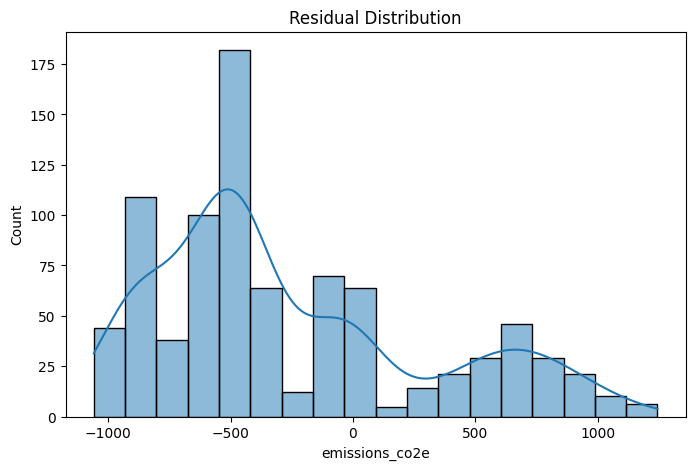

In [26]:
residuals = y_test - pred_rf

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

In [ ]:
# B. TIME-SERIES MODELING

In [27]:
# !pip install statsmodels

In [28]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [29]:
# Prepared time-series
ts = df[['date', 'emissions_co2e']].copy()
ts.set_index('date', inplace=True)

In [45]:
# 1.ARIMA----short-term operational planning

model_arima = ARIMA(ts['emissions_co2e'], order=(1,1,1))
fit_arima = model_arima.fit()

forecast_arima = fit_arima.forecast(12)

C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  

In [46]:
# 2. Exponential Smoothing----------Use for long-term strategy

model_es = ExponentialSmoothing(ts['emissions_co2e'], trend='add')
fit_es = model_es.fit()

forecast_es = fit_es.forecast(12)

C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


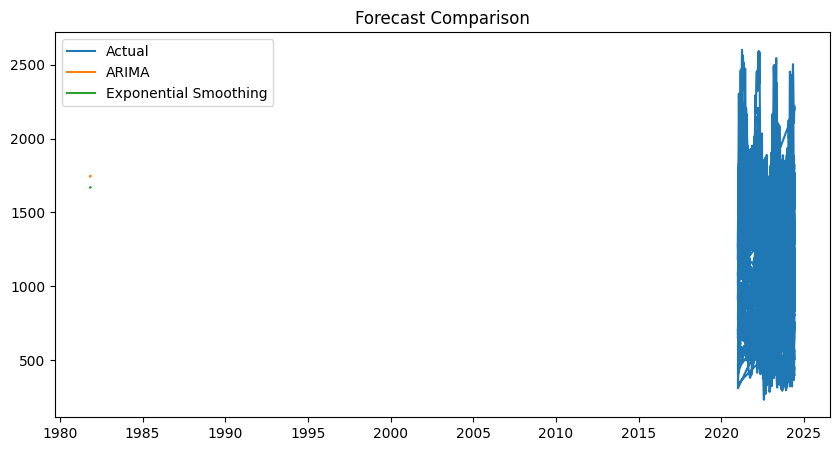

In [47]:
# Visualization

plt.figure(figsize=(10,5))

plt.plot(ts['emissions_co2e'], label='Actual')
plt.plot(forecast_arima, label='ARIMA')
plt.plot(forecast_es, label='Exponential Smoothing')

plt.legend()
plt.title("Forecast Comparison")
plt.show()

In [ ]:
# Business Unit Analysis

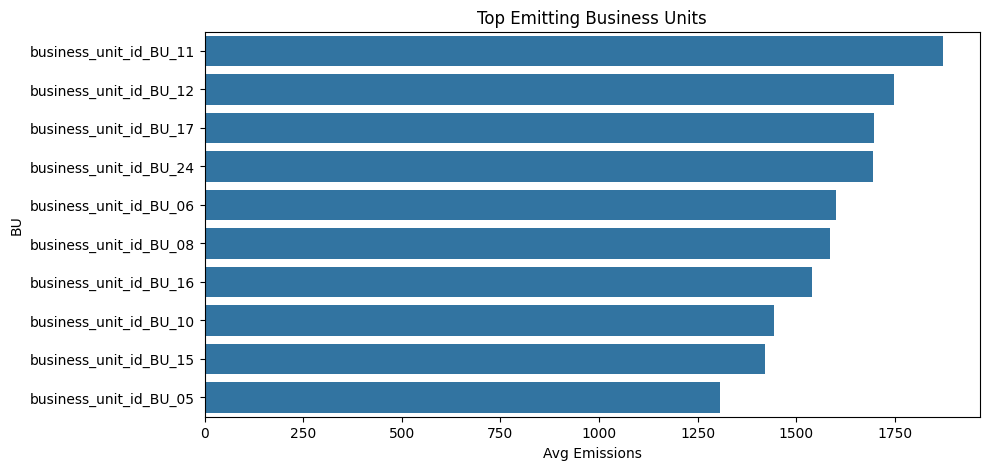

In [33]:
bu_cols = [col for col in df.columns if "business_unit_id_" in col]

bu_avg = {}

for col in bu_cols:
    bu_avg[col] = df[df[col] == 1]['emissions_co2e'].mean()

bu_df = pd.DataFrame(list(bu_avg.items()), columns=['BU', 'Avg Emissions'])
bu_df = bu_df.sort_values(by='Avg Emissions', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Avg Emissions', y='BU', data=bu_df.head(10))
plt.title("Top Emitting Business Units")
plt.show()

In [ ]:
# Time-Series Per Business Unit Forecasting

In [34]:
# one business unit

selected_bu = bu_cols[0]

bu_ts = df[df[selected_bu] == 1][['date', 'emissions_co2e']]
bu_ts.set_index('date', inplace=True)

bu_ts.head()

,emissions_co2e
date,
2021-01-04,460.01
2021-01-11,562.47
2021-01-18,594.75
2021-01-25,763.27
2021-02-01,751.41


In [35]:
# ARIMA for that unit
model_arima_bu = ARIMA(bu_ts['emissions_co2e'], order=(1,1,1))
fit_arima_bu = model_arima_bu.fit()

forecast_bu = fit_arima_bu.forecast(12)

forecast_bu

C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


2024-06-17    683.451801
2024-06-24    652.188104
2024-07-01    631.592743
2024-07-08    618.025285
2024-07-15    609.087548
2024-07-22    603.199700
2024-07-29    599.321004
2024-08-05    596.765863
2024-08-12    595.082632
2024-08-19    593.973781
2024-08-26    593.243312
2024-09-02    592.762106
Freq: W-MON, Name: predicted_mean, dtype: float64

C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
C:\Users\IRANI\anaconda3\envs\TensorFlow\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


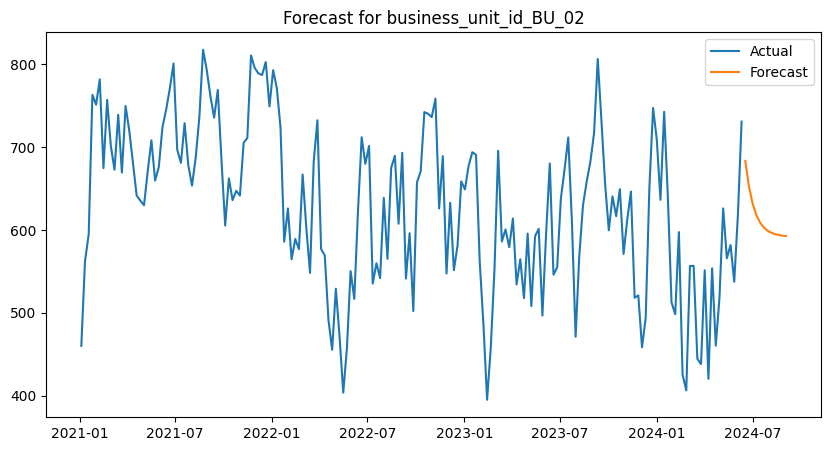

In [36]:
selected_bu = bu_cols[0]

bu_ts = df[df[selected_bu] == 1][['date', 'emissions_co2e']]
bu_ts.set_index('date', inplace=True)

model = ARIMA(bu_ts['emissions_co2e'], order=(1,1,1))
fit = model.fit()

forecast = fit.forecast(12)

plt.figure(figsize=(10,5))
plt.plot(bu_ts['emissions_co2e'], label='Actual')
plt.plot(forecast, label='Forecast')

plt.legend()
plt.title(f"Forecast for {selected_bu}")
plt.show()

In [ ]:
# Evaluation Metrics

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# R² Score

In [49]:
from sklearn.metrics import r2_score

r2_lr = r2_score(y_test, pred_lr)
r2_rf = r2_score(y_test, pred_rf)

print("Linear Regression R2:", r2_lr)
print("Random Forest R2:", r2_rf)

Linear Regression R2: -0.38107419892051975
Random Forest R2: -0.7972836480576597


In [ ]:
# Observation:-
# R² close to 1 -- strong model
# R² near 0 -- weak model

In [ ]:
# MAPE

In [50]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_lr = mape(y_test, pred_lr)
mape_rf = mape(y_test, pred_rf)

print("Linear Regression MAPE:", mape_lr)
print("Random Forest MAPE:", mape_rf)

Linear Regression MAPE: 63.81839340748889
Random Forest MAPE: 77.0328863693195


In [ ]:
# observation :- Linear Regression MAPE is more accurate predictions in real-world terms

In [ ]:
# Model Comparison Table-------Full performance comparison in one place

In [51]:
final_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2': [r2_lr, r2_rf],
    'MAPE': [mape_lr, mape_rf]
})

final_results

,Model,MAE,RMSE,R2,MAPE
0,Linear Regression,462.098670,537.640028,-0.381074,63.818393
1,Random Forest,543.899491,613.326035,-0.797284,77.032886


In [ ]:
# observation:- clearly identify the best model is liner regression model which has Lower MAE,RMSE,MAPE

In [ ]:
# Feature Importance

In [52]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
11,business_unit_id_BU_03,0.102952
19,business_unit_id_BU_11,0.099447
10,business_unit_id_BU_02,0.095464
17,business_unit_id_BU_09,0.094589
27,business_unit_id_BU_19,0.089735
12,business_unit_id_BU_04,0.088741
5,temperature_avg,0.076721
26,business_unit_id_BU_18,0.043049
7,mitigation_action_flag,0.039598
21,business_unit_id_BU_13,0.032224


In [ ]:
# Better Visualization

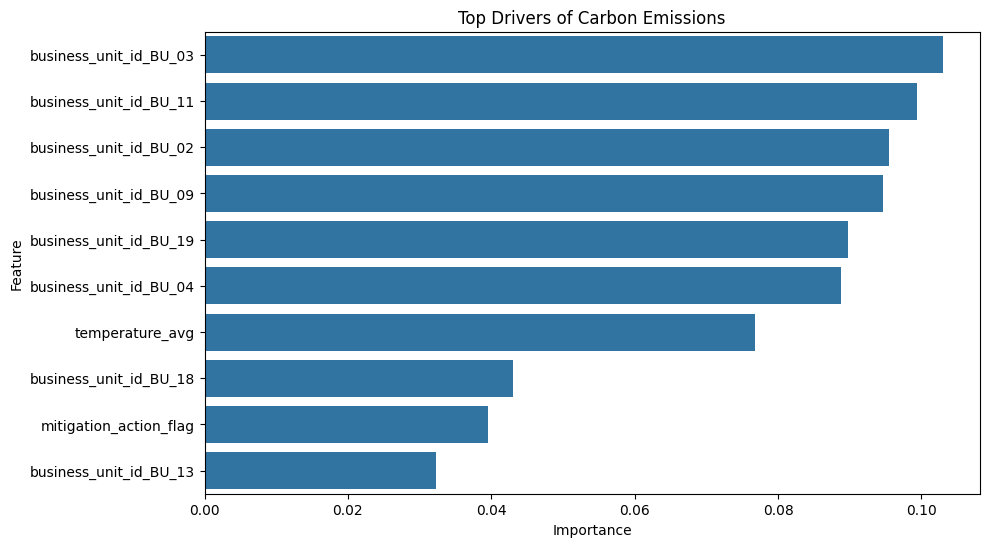

In [53]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top Drivers of Carbon Emissions")
plt.show()

In [ ]:
# Highest Emitting Units---Aggregate emissions per unit

In [54]:
bu_cols = [col for col in df.columns if "business_unit_id_" in col]

bu_avg = {}

for col in bu_cols:
    bu_avg[col] = df[df[col] == 1]['emissions_co2e'].mean()

bu_df = pd.DataFrame(list(bu_avg.items()), columns=['BU', 'Avg Emissions'])
bu_df = bu_df.sort_values(by='Avg Emissions', ascending=False)

bu_df.head()

,BU,Avg Emissions
9,business_unit_id_BU_11,1870.616444
10,business_unit_id_BU_12,1747.999111
15,business_unit_id_BU_17,1695.920611
22,business_unit_id_BU_24,1694.908278
4,business_unit_id_BU_06,1601.145056


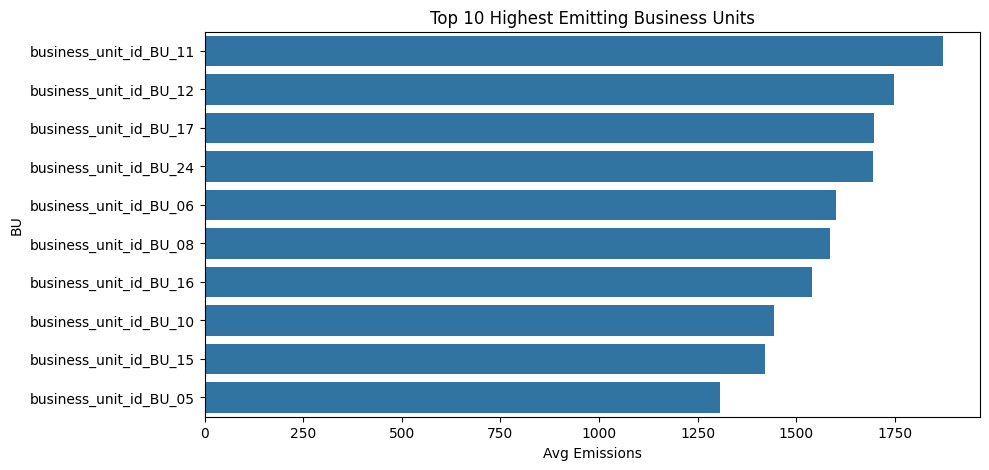

In [55]:
# plot

plt.figure(figsize=(10,5))
sns.barplot(x='Avg Emissions', y='BU', data=bu_df.head(10))
plt.title("Top 10 Highest Emitting Business Units")
plt.show()

In [ ]:
# Final Summary:-

# Best Regression Model ---Linear Regression
# Best Overall Model ---ARIMA
# Reason ---captures time dependency